# Inference on UK Biobank summary statistics via p-thinning

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

## Tuning parameter exploration

1. Load a small subset of `bmi_summary_stats.csv` (a genome-wide association
   study of BMI; one row per SNP, with its association p-value).
2. Identify SNPs genome-wide significant by the standard threshold
   $5 \times 10^{-8}$.

In [4]:
df = pd.read_csv("../data/bmi_summary_stats.csv", nrows=100_000)
df.head()

,snp,p_value,effect_sign
0,rs10399793,0.770,1.0
1,rs2462492,0.540,1.0
2,rs114608975,0.210,1.0
3,rs6702460,0.230,1.0
4,rs8179466,0.072,-1.0


In [5]:
epsilon = 0.5
p = df["p_value"].to_numpy()

rng = np.random.default_rng(0)

U = rng.uniform(0, 1, size=len(p))
C = rng.binomial(1, epsilon, size=len(p))

p1 = p**epsilon * (C + (1 - C) * U)
p2 = p ** (1 - epsilon) * ((1 - C) + C * U)

df["p1"] = p1
df["p2"] = p2
df[["snp", "p_value", "p1", "p2"]].head()

,snp,p_value,p1,p2
0,rs10399793,0.770,0.877497,0.558932
1,rs2462492,0.540,0.198252,0.734847
2,rs114608975,0.210,0.458257,0.018776
3,rs6702460,0.230,0.479583,0.007926
4,rs8179466,0.072,0.268327,0.218223


## Threshold examination

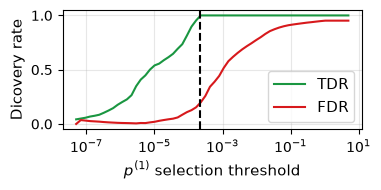

In [6]:
threshold = 5e-8
epsilon = 0.5
thresholds = 5 * np.logspace(-8, 0, 60)
alpha = 0.05
oracle = df["p_value"] < threshold
# uniform 
nulls = rng.uniform(size=len(p))

tdr, fdr = [], []
for t in thresholds:
    discovered = (df["p1"] < t) & (df["p2"] < alpha)
    tdr.append((discovered & oracle).sum() / oracle.sum())
    fdr.append((discovered & (~oracle)).sum() / discovered.sum())


fig, ax = plt.subplots(figsize=(4, 2))
ax.plot(thresholds, tdr, label="TDR", color="#1a9641")
ax.plot(thresholds, fdr, label="FDR", color="#d7191c")
# ax.plot(thresholds, null_fdr, label="Nulls", ls='--', color="grey")
ax.axvline(
    (5e-8) ** epsilon, color="black", linestyle="--",
    # label=r"$(5\times10^{-8})^\epsilon$"
)
ax.set_xscale("log")
# ax.set_yscale('log')
ax.set_xlabel(r"$p^{(1)}$ selection threshold", fontsize=11)
ax.set_ylabel("Dicovery rate", fontsize=11)
# ax.set_title(r"Testing quality (vs. $p < 5\times10^{-8}$)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/ukb_threshold_discoveries.png", dpi=300, bbox_inches='tight')
plt.show()

## Epsilon examination

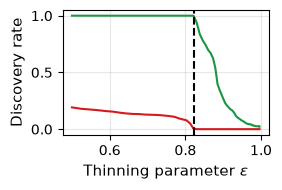

In [7]:
threshold = 5e-8
epsilons = (1 - 2**np.linspace(-8, -1, 100))[::-1]

alpha = 0.05
oracle = df["p_value"] < threshold
# uniform 
nulls = rng.uniform(size=len(p))

tdr, fdr = [], []
for eps in epsilons:
    df["p1_e"] = p**eps * (C + (1 - C) * U)
    df["p2_e"] = p ** (1 - eps) * ((1 - C) + C * U)
    t = threshold ** eps

    discovered = (df["p1_e"] <= t) & (df["p2_e"] <= alpha)
    tdr.append((discovered & oracle).sum() / oracle.sum())
    fdr.append((discovered & (~oracle)).sum() / discovered.sum())


fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(epsilons, tdr, label="TDR", color="#1a9641")
ax.plot(epsilons, fdr, label="FDR", color="#d7191c")
ax.axvline(
    1 - np.log(5e-2) / np.log(5e-8), color="black", linestyle="--",
)
ax.set_xlabel(r"Thinning parameter $\epsilon$", fontsize=11)
ax.set_ylabel("Discovery rate", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/ukb_epsilon_discoveries.png", dpi=300, bbox_inches='tight')
plt.show()

## Inference Evaluation

In [ ]:

from scipy.stats import norm
from scipy import stats
from joblib import Parallel, delayed
from pthin import (
    pthin, pcarve_estimate, truncgauss_estimate, normal_carving_estimate,
    pcarve_threshold, truncgauss_pvalue, normal_carving_pvalue,
)

# Load data
N_SUBSET = 100_000
df_pipeline = pd.read_csv(
    "../data/t2d_summary_stats.csv",
    # skiprows=range(1, 10^5 + 1)#
    # nrows=N_SUBSET,
)
df_pipeline.head()
print(df_pipeline.shape)

(5021057, 3)


In [ ]:
# Recover the (signed) Z-score from the two-sided p-value and effect sign
Z = df_pipeline["effect_sign"].to_numpy() * norm.isf(df_pipeline["p_value"].to_numpy() / 2)
Z[Z == np.inf] = Z[~(Z == np.inf)].max()

# Create validation set
rng = np.random.default_rng(1)
W = rng.normal(0, 1, size=len(Z))
Z_train = (Z + W) / np.sqrt(2)
Z_test = (Z - W) / np.sqrt(2)

# Two-sided p-value of the train split, against theta0=0
p_train = norm.sf(np.abs(Z_train))
sign_train = np.sign(Z_train)

# Settings
alpha = 0.05 / 2  # Divide by 2 for 2-sided test
threshold = 5e-8
Z_threshold = norm.isf(threshold)

In [ ]:
# Classical inference
naive_sel = p_train <= threshold

naive_estimates = Z_train[naive_sel]
naive_mse = np.mean((naive_estimates - Z_test[naive_sel]) ** 2)

naive_reject_sel = p_train[naive_sel] < alpha
naive_rej = naive_reject_sel.sum()

print(f"Naive: {naive_sel.sum()} selected, MSE = {naive_mse:.3f}, rejections = {naive_rej}")

Naive: 1989 selected, MSE = 2.938, rejections = 1989


In [ ]:
# Conditional
cond_sel = naive_sel

def csi_point_estimates(x, t):
    # x : observed statistic
    # t : selection threshold on x, on the Z-score scale (not `threshold`,
    # the raw p-value -- passing that would leave the truncation point at
    # ~0, i.e. essentially no selective-inference correction at all)
    try:
        mle = truncgauss_estimate(x, c=t, estimator="mle")
        return mle
    except Exception as e:
        print(e)
        return np.nan
    
def conditional_pvalue(x, t):
    return truncgauss_pvalue(x, 0.0, c=t, scale=1.0)

cond_estimates = np.array(
    Parallel(n_jobs=-1)(
        delayed(csi_point_estimates)(x, Z_threshold)
        for x in np.abs(Z_train[cond_sel])
    )
)

cond_estimates *= sign_train[cond_sel]

cond_pvals = np.array(
    Parallel(n_jobs=-1)(
        delayed(conditional_pvalue)(x, Z_threshold)
        for x in np.abs(Z_train[cond_sel])
    )
)

cond_mse = np.mean((cond_estimates - Z_test[cond_sel]) ** 2)
cond_reject_sel = cond_pvals < alpha
cond_rej = cond_reject_sel.sum()

cond_reject_full = np.zeros(len(Z), dtype=bool)
cond_reject_full[cond_sel] = cond_reject_sel

print(f"Conditional: {cond_sel.sum()} selected, MSE = {cond_mse:.3f}, rejections = {cond_rej}")

Conditional: 1989 selected, MSE = 6.852, rejections = 1347


In [6]:
# p-thinning
epsilon = 1 - np.log(alpha) / np.log(threshold)
p_threshold = threshold ** epsilon
p1, p2 = pthin(p_train, epsilon=epsilon, rng=rng)
p_sel = p1 <= p_threshold

pthin_reject_sel = p2[p_sel] <= alpha
pthin_rej = pthin_reject_sel.sum()

pthin_reject_full = np.zeros(len(Z), dtype=bool)
pthin_reject_full[p_sel] = pthin_reject_sel

print(f"p-thinning: {p_sel.sum()} selected, MSE = NA, rejections = {pthin_rej}")

pthin_selected_matching_cond = (p_sel & cond_sel).sum()
pthin_rejected_matching_cond = (pthin_reject_full & cond_reject_full).sum()
print(f"p-thinning selected {pthin_selected_matching_cond} hypotheses also selected by the conditional method.")
print(f"p-thinning rejected {pthin_reject_sel.sum()} hypotheses; "
      f"{pthin_rejected_matching_cond} of these are also rejected by the conditional method.")

p-thinning: 2147 selected, MSE = NA, rejections = 1989
p-thinning selected 1989 hypotheses also selected by the conditional method.
p-thinning rejected 1989 hypotheses; 1347 of these are also rejected by the conditional method.


In [ ]:
# Data thinning
gamma = 0.01 # np.sqrt((1 - epsilon) / epsilon)
W_sel = rng.normal(0, 1, size=len(Z_train))
X1 = (Z_train + gamma * W_sel) / np.sqrt(1 + gamma**2)
X2 = ((Z_train - W_sel/ gamma) / np.sqrt(1 + 1/gamma**2))

dc_sel = np.abs(X1) >= Z_threshold
dt_estimates = X2[dc_sel]
dt_mse = np.mean((dt_estimates - Z_test[dc_sel]) ** 2)

dt_pvals = norm.sf(X2[dc_sel])
dt_reject_sel = dt_pvals < alpha
dt_rej = dt_reject_sel.sum()

# Comparison to classical selection
dt_reject_full = np.zeros(len(Z), dtype=bool)
dt_reject_full[dc_sel] = dt_reject_sel

print(f"Data thinning: {dc_sel.sum()} selected, MSE = {dt_mse:.3f}, rejections = {dt_rej}")

dt_selected_matching_cond = (dc_sel & cond_sel).sum()
dt_rejected_matching_cond = (dt_reject_full & cond_reject_full).sum()
print(f"Data thinning selected {dt_selected_matching_cond} hypotheses also selected by the conditional method.")
print(f"Data thinning rejected {dt_reject_sel.sum()} hypotheses; "
      f"{dt_rejected_matching_cond} of these are also rejected by the conditional method.")

Data thinning: 1988 selected, MSE = 54.788, rejections = 42
Data thinning selected 1986 hypotheses also selected by the conditional method.
Data thinning rejected 42 hypotheses; 29 of these are also rejected by the conditional method.


In [8]:
# p-carving
def pcarve_point_estimates(x, epsilon, b):
    # x : observed statistic
    # b : selection threshold
    try:
        mle = pcarve_estimate(
            x, 0.0, a=0.0, b=b, epsilon=epsilon, estimator="mle", input_type="statistic",
            epsabs=1e-4, epsrel=1e-4, limit=50,
        )
        return mle
    except Exception as e:
        print(e)
        return 0

pthin_estimates = np.array(
    Parallel(n_jobs=-1)(
        delayed(pcarve_point_estimates)(x, epsilon, p_threshold)
        for _, x in enumerate(np.abs(Z_train[p_sel]))
    )
)

pthin_estimates *= sign_train[p_sel]  # Set sign
pthin_mse = np.mean((pthin_estimates - Z_test[p_sel]) ** 2)

pcarve_t_star = pcarve_threshold(alpha, a=1e-12, b=p_threshold, epsilon=epsilon)
pcarve_reject_sel = p_train[p_sel] <= pcarve_t_star
pcarve_rej = pcarve_reject_sel.sum()

pcarve_reject_full = np.zeros(len(Z), dtype=bool)
pcarve_reject_full[p_sel] = pcarve_reject_sel

print(f"p-carving: {p_sel.sum()} selected, MSE = {pthin_mse:.3f}, rejections = {pcarve_rej}")

pthin_selected_matching_cond = (p_sel & cond_sel).sum()
pthin_rejected_matching_cond = (pthin_reject_full & cond_reject_full).sum()
print(f"p-thinning selected {pthin_selected_matching_cond} hypotheses also selected by the conditional method.")
print(f"p-carving rejected {pthin_reject_sel.sum()} hypotheses; "
      f"{pthin_rejected_matching_cond} of these are also rejected by the conditional method.")

p-carving: 2147 selected, MSE = 2.767, rejections = 1989
p-thinning selected 1989 hypotheses also selected by the conditional method.
p-carving rejected 1989 hypotheses; 1347 of these are also rejected by the conditional method.


In [ ]:
# Data carving
def data_carving_point_estimates(x, c_alpha, gamma):
    x_nc = x / np.sqrt(1 + gamma**2)
    sigma_x_nc = 1 / np.sqrt(1 + gamma**2)
    rho_nc = 1 / np.sqrt(1 + gamma**2)
    mle = np.sqrt(1 + gamma**2) * normal_carving_estimate(
        x_nc, c=c_alpha, sigma_x=sigma_x_nc, sigma_y=1.0, rho=rho_nc, estimator="mle"
    )
    return mle

# Hypothesis test: normal_carving_pvalue is the exact conditional p-value
# for H0: theta=0 given the same selection event (Y = X1, c = Z_threshold,
# rho = 1/sqrt(1+gamma**2)) used for selection above.
def data_carving_pvalue(x, c_alpha, gamma):
    x_nc = x / np.sqrt(1 + gamma**2)
    sigma_x_nc = 1 / np.sqrt(1 + gamma**2)
    rho_nc = 1 / np.sqrt(1 + gamma**2)
    return normal_carving_pvalue(x_nc, 0.0, c_alpha, sigma_x=sigma_x_nc, sigma_y=1.0, rho=rho_nc)

data_carve_estimates = np.array(
    Parallel(n_jobs=-1)(
        delayed(data_carving_point_estimates)(x, Z_threshold, gamma)
        for _, x in enumerate(np.abs(Z_train[dc_sel]))
    )
)

data_carve_estimates *= sign_train[dc_sel]
dc_mse = np.mean((data_carve_estimates - Z_test[dc_sel]) ** 2)

dc_pvals = np.array(
    Parallel(n_jobs=-1)(
        delayed(data_carving_pvalue)(x, Z_threshold, gamma)
        for _, x in enumerate(np.abs(Z_train[dc_sel]))
    )
)
dc_reject_sel = dc_pvals < alpha
dc_rej = dc_reject_sel.sum()

# Comparison to classical selection
dc_reject_full = np.zeros(len(Z), dtype=bool)
dc_reject_full[dc_sel] = dc_reject_sel

print(f"Data carving: {dc_sel.sum()} selected, MSE = {dc_mse:.3f}, rejections = {dc_rej}")

dc_selected_matching_cond = (dc_sel & cond_sel).sum()
dc_rejected_matching_cond = (dc_reject_full & cond_reject_full).sum()
print(f"Data carving selected {dc_selected_matching_cond} hypotheses also selected by the conditional method.")
print(f"Data carving rejected {dc_reject_sel.sum()} hypotheses; "
      f"{dc_rejected_matching_cond} of these are also rejected by the conditional method.")

Data carving: 1988 selected, MSE = 6.838, rejections = 1347
Data carving selected 1986 hypotheses also selected by the conditional method.
Data carving rejected 1347 hypotheses; 1347 of these are also rejected by the conditional method.


In [ ]:
# Data thinning with gamma=1
gamma = 1 # np.sqrt((1 - epsilon) / epsilon)
W_sel = rng.normal(0, 1, size=len(Z_train))
X1 = (Z_train + gamma * W_sel) / np.sqrt(1 + gamma**2)
X2 = ((Z_train - W_sel/ gamma) / np.sqrt(1 + 1/gamma**2))

dc_sel = np.abs(X1) >= Z_threshold
dt_estimates = X2[dc_sel]
dt_mse = np.mean((dt_estimates - Z_test[dc_sel]) ** 2)

dt_pvals = norm.sf(X2[dc_sel])
dt_reject_sel = dt_pvals < alpha
dt_rej = dt_reject_sel.sum()

# Comparison to classical selection
dt_reject_full = np.zeros(len(Z), dtype=bool)
dt_reject_full[dc_sel] = dt_reject_sel

print(f"Data thinning: {dc_sel.sum()} selected, MSE = {dt_mse:.3f}, rejections = {dt_rej}")

dt_selected_matching_cond = (dc_sel & cond_sel).sum()
dt_rejected_matching_cond = (dt_reject_full & cond_reject_full).sum()
print(f"Data thinning selected {dt_selected_matching_cond} hypotheses also selected by the conditional method.")
print(f"Data thinning rejected {dt_reject_sel.sum()} hypotheses; "
      f"{dt_rejected_matching_cond} of these are also rejected by the conditional method.")


# Data carving
data_carve_estimates = np.array(
    Parallel(n_jobs=-1)(
        delayed(data_carving_point_estimates)(x, Z_threshold, gamma)
        for _, x in enumerate(np.abs(Z_train[dc_sel]))
    )
)

data_carve_estimates *= sign_train[dc_sel]
dc_mse = np.mean((data_carve_estimates - Z_test[dc_sel]) ** 2)

dc_pvals = np.array(
    Parallel(n_jobs=-1)(
        delayed(data_carving_pvalue)(x, Z_threshold, gamma)
        for _, x in enumerate(np.abs(Z_train[dc_sel]))
    )
)
dc_reject_sel = dc_pvals < alpha
dc_rej = dc_reject_sel.sum()

# Comparison to classical selection
dc_reject_full = np.zeros(len(Z), dtype=bool)
dc_reject_full[dc_sel] = dc_reject_sel

print(f"Data carving: {dc_sel.sum()} selected, MSE = {dc_mse:.3f}, rejections = {dc_rej}")

dc_selected_matching_cond = (dc_sel & cond_sel).sum()
dc_rejected_matching_cond = (dc_reject_full & cond_reject_full).sum()
print(f"Data carving selected {dc_selected_matching_cond} hypotheses also selected by the conditional method.")
print(f"Data carving rejected {dc_reject_sel.sum()} hypotheses; "
      f"{dc_rejected_matching_cond} of these are also rejected by the conditional method.")

Data thinning: 714 selected, MSE = 10.134, rejections = 493
Data thinning selected 698 hypotheses also selected by the conditional method.
Data thinning rejected 493 hypotheses; 488 of these are also rejected by the conditional method.
Data carving: 714 selected, MSE = 2.377, rejections = 699
Data carving selected 698 hypotheses also selected by the conditional method.
Data carving rejected 699 hypotheses; 685 of these are also rejected by the conditional method.
